<a href="https://colab.research.google.com/github/Juan-Medinaa/Inferencia/blob/main/BayesianModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Bayesian Model Prototype

Notebook base con las dependencias del proyecto.

In [ ]:
import sys
!{sys.executable} -m pip install understatapi tqdm matplotlib scikit-learn pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.7/537.7 kB 5.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.4/159.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.5/153.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.1/138.1 kB 4.9 MB/s eta 0:00:00
  Created wheel for understatapi: filename=understatapi-0.7.1-py3-none-any.whl size=15443 sha256=772875eb84ce6f0ee902e32877c80f94ef9fd0d66d401bc2bbca4d391017005d
  Stored in directory: /root/.cache/pip/wheels/38/de/d6/f84cd8cb7746c9685b36beb27b8840f43e8b3f93cf288343c5
Successfully built understatapi
  Attem

In [ ]:
import warnings
warnings.filterwarnings("ignore", message="PyTensor could not link to a BLAS")

from understatapi import UnderstatClient
import pandas as pd
import numpy as np
from time import sleep
from tqdm.auto import tqdm
from pprint import pprint

import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from scipy.stats import poisson

## 2. Extracción de Datos Históricos de Rendimiento Deportivo

En esta sección se define el alcance temporal del proyecto y se extrae secuencialmente el histórico de partidos de la Bundesliga a través de la API, consolidando una base de datos multi-temporada que servirá como el conjunto de entrenamiento para estimar los parámetros latentes del modelo bayesiano.

In [ ]:
# Configuración
LEAGUE = "Bundesliga"    # "EPL", "La_Liga", "Bundesliga", "Serie_A", "Ligue_1", "RFPL"
SEASON = ["2021","2022", "2023", "2024", "2025"]

In [ ]:
def get_league_matches(league: str, seasons: list[str]):
    all_matches = []
    with UnderstatClient() as us:
        for season in seasons:
            matches = us.league(league=league).get_match_data(season=season)
            all_matches.extend(matches)
    return all_matches

raw_matches = get_league_matches(LEAGUE, SEASON)
print(f"Total de partidos: {len(raw_matches)}")
pprint(raw_matches[0])

Total de partidos: 1530
{'a': {'id': '117', 'short_title': 'BAY', 'title': 'Bayern Munich'},
 'datetime': '2021-08-13 18:30:00',
 'forecast': {'d': '0.2047', 'l': '0.594', 'w': '0.2013'},
 'goals': {'a': '1', 'h': '1'},
 'h': {'id': '130', 'short_title': 'BMG', 'title': 'Borussia M.Gladbach'},
 'id': '17516',
 'isResult': True,
 'xG': {'a': '2.91794', 'h': '1.98777'}}


In [ ]:
def format_fixtures(matches: list[dict]) -> pd.DataFrame:
    rows = []
    for m in matches:
        if not m.get("isResult"):
            continue

        h_goals = int(m["goals"]["h"])
        a_goals = int(m["goals"]["a"])

        if h_goals > a_goals:
            result = "H"
        elif h_goals < a_goals:
            result = "A"
        else:
            result = "D"

        rows.append({
            "date": m["datetime"],
            "home_team": m["h"]["title"],
            "away_team": m["a"]["title"],
            "yg1": h_goals,
            "yg2": a_goals,
            "result": result
        })

    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(df["date"])
    return df.sort_values("date").reset_index(drop=True)

fixtures = format_fixtures(raw_matches)
print(f"Partidos jugados: {len(fixtures)}")
fixtures.head()

Partidos jugados: 1530


,date,home_team,away_team,yg1,yg2,result
0,2021-08-13 18:30:00,Borussia M.Gladbach,Bayern Munich,1,1,D
1,2021-08-14 13:30:00,Arminia Bielefeld,Freiburg,0,0,D
2,2021-08-14 13:30:00,Augsburg,Hoffenheim,0,4,A
3,2021-08-14 13:30:00,VfB Stuttgart,Greuther Fuerth,5,1,H
4,2021-08-14 13:30:00,Union Berlin,Bayer Leverkusen,1,1,D


In [ ]:
n_teams = len(fixtures["home_team"].unique())

teams = (
    fixtures[["home_team"]]
    .drop_duplicates()
    .sort_values("home_team")
    .reset_index(drop=True)
    .assign(team_index=np.arange(n_teams))
    .rename(columns={"home_team": "team"})
)

df = (
    fixtures
    .merge(teams, left_on="home_team", right_on="team")
    .rename(columns={"team_index": "hg"})
    .drop(["team"], axis=1)
    .merge(teams, left_on="away_team", right_on="team")
    .rename(columns={"team_index": "ag"})
    .drop(["team"], axis=1)
    .sort_values("date")
)

print(f"Equipos: {n_teams}")
print(teams.to_string())
print()
df.head()

Equipos: 25
                      team  team_index
0        Arminia Bielefeld           0
1                 Augsburg           1
2         Bayer Leverkusen           2
3            Bayern Munich           3
4                   Bochum           4
5        Borussia Dortmund           5
6      Borussia M.Gladbach           6
7                Darmstadt           7
8      Eintracht Frankfurt           8
9               FC Cologne           9
10           FC Heidenheim          10
11                Freiburg          11
12         Greuther Fuerth          12
13            Hamburger SV          13
14           Hertha Berlin          14
15              Hoffenheim          15
16           Holstein Kiel          16
17                Mainz 05          17
18  RasenBallsport Leipzig          18
19              Schalke 04          19
20               St. Pauli          20
21            Union Berlin          21
22           VfB Stuttgart          22
23           Werder Bremen          23
24           

,date,home_team,away_team,yg1,yg2,result,hg,ag
0,2021-08-13 18:30:00,Borussia M.Gladbach,Bayern Munich,1,1,D,6,3
1,2021-08-14 13:30:00,Arminia Bielefeld,Freiburg,0,0,D,0,11
2,2021-08-14 13:30:00,Augsburg,Hoffenheim,0,4,A,1,15
3,2021-08-14 13:30:00,VfB Stuttgart,Greuther Fuerth,5,1,H,22,12
4,2021-08-14 13:30:00,Union Berlin,Bayer Leverkusen,1,1,D,21,2


In [ ]:
TEST_SIZE = 306

train = df.iloc[:-TEST_SIZE]
test = df.iloc[-TEST_SIZE:]

goals_home_obs = train["yg1"].values
goals_away_obs = train["yg2"].values
home_team = train["hg"].values
away_team = train["ag"].values

print(f"Train: {len(train)} partidos")
print(f"Test: {len(test)} partidos")

Train: 1224 partidos
Test: 306 partidos


In [ ]:
# Definimos una fecha de corte en lugar de un número fijo de partidos
# La temporada 2025/2026 de la Bundesliga comenzó en agosto de 2025
FECHA_CORTE = "2025-08-01"

# Hacemos la división basada en la condición temporal
train = df[df["date"] < FECHA_CORTE]
test = df[df["date"] >= FECHA_CORTE]

# Extraemos las variables para el modelo (se mantiene igual, pero con los nuevos conjuntos)
goals_home_obs = train["yg1"].values
goals_away_obs = train["yg2"].values
home_team = train["hg"].values
away_team = train["ag"].values

print(f"Train (Temporadas anteriores): {len(train)} partidos")
print(f"Test (Temporada 2025): {len(test)} partidos")

Train (Temporadas anteriores): 1224 partidos
Test (Temporada 2025): 306 partidos


#verificar temporada de test de prueba


In [ ]:
print('Primeros 5 partidos de los datos de prueba:')
print(test[['date', 'home_team', 'away_team', 'yg1', 'yg2']].head())

Primeros 5 partidos de los datos de prueba:
                    date            home_team               away_team  yg1  \
1224 2025-08-22 18:30:00        Bayern Munich  RasenBallsport Leipzig    6   
1225 2025-08-23 13:30:00        FC Heidenheim               Wolfsburg    1   
1226 2025-08-23 13:30:00     Bayer Leverkusen              Hoffenheim    1   
1227 2025-08-23 13:30:00         Union Berlin           VfB Stuttgart    2   
1228 2025-08-23 13:30:00  Eintracht Frankfurt           Werder Bremen    4   

      yg2  
1224    0  
1225    3  
1226    2  
1227    1  
1228    1  


In [ ]:
print('Últimos 10 partidos de los datos de prueba:')
display(test[['date', 'home_team', 'away_team', 'yg1', 'yg2']].tail(10))

Últimos 10 partidos de los datos de prueba:


,date,home_team,away_team,yg1,yg2
1520,2026-05-10 17:30:00,Mainz 05,Union Berlin,1,3
1521,2026-05-16 13:30:00,Bayer Leverkusen,Hamburger SV,1,1
1522,2026-05-16 13:30:00,Bayern Munich,FC Cologne,5,1
1523,2026-05-16 13:30:00,Borussia M.Gladbach,Hoffenheim,4,0
1524,2026-05-16 13:30:00,Eintracht Frankfurt,VfB Stuttgart,2,2
1525,2026-05-16 13:30:00,Freiburg,RasenBallsport Leipzig,4,1
1526,2026-05-16 13:30:00,FC Heidenheim,Mainz 05,0,2
1527,2026-05-16 13:30:00,St. Pauli,Wolfsburg,1,3
1528,2026-05-16 13:30:00,Union Berlin,Augsburg,4,0
1529,2026-05-16 13:30:00,Werder Bremen,Borussia Dortmund,0,2


In [ ]:
  import pytensor.tensor as pt

  with pm.Model() as model:
      home = pm.Flat("home")

      tau_att = pm.Gamma("tau_att", 0.1, 0.1)
      atts_star = pm.Normal("atts_star", mu=0, tau=tau_att, shape=n_teams)

      tau_def = pm.Gamma("tau_def", 0.1, 0.1)
      def_star = pm.Normal("def_star", mu=0, tau=tau_def, shape=n_teams)

      atts = pm.Deterministic("atts", atts_star - pt.mean(atts_star))
      defs = pm.Deterministic("defs", def_star - pt.mean(def_star))

      home_theta = pt.exp(home + atts[home_team] + defs[away_team])
      away_theta = pt.exp(atts[away_team] + defs[home_team])

      home_goals = pm.Poisson("home_goals", mu=home_theta, observed=goals_home_obs)
      away_goals = pm.Poisson("away_goals", mu=away_theta, observed=goals_away_obs)

In [ ]:
with model:
    trace = pm.sample(2000, tune=1000, cores=4, return_inferencedata=True)

Output()

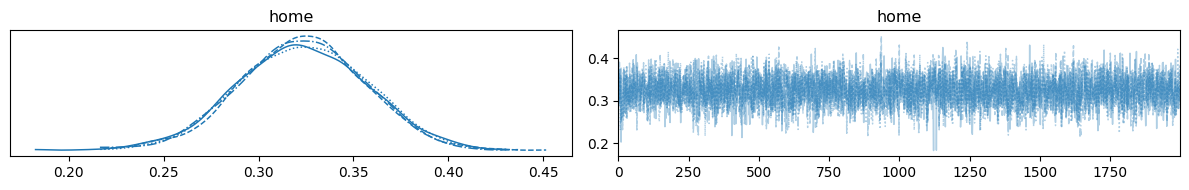

In [ ]:
az.plot_trace(trace, var_names=["home"])
plt.tight_layout()

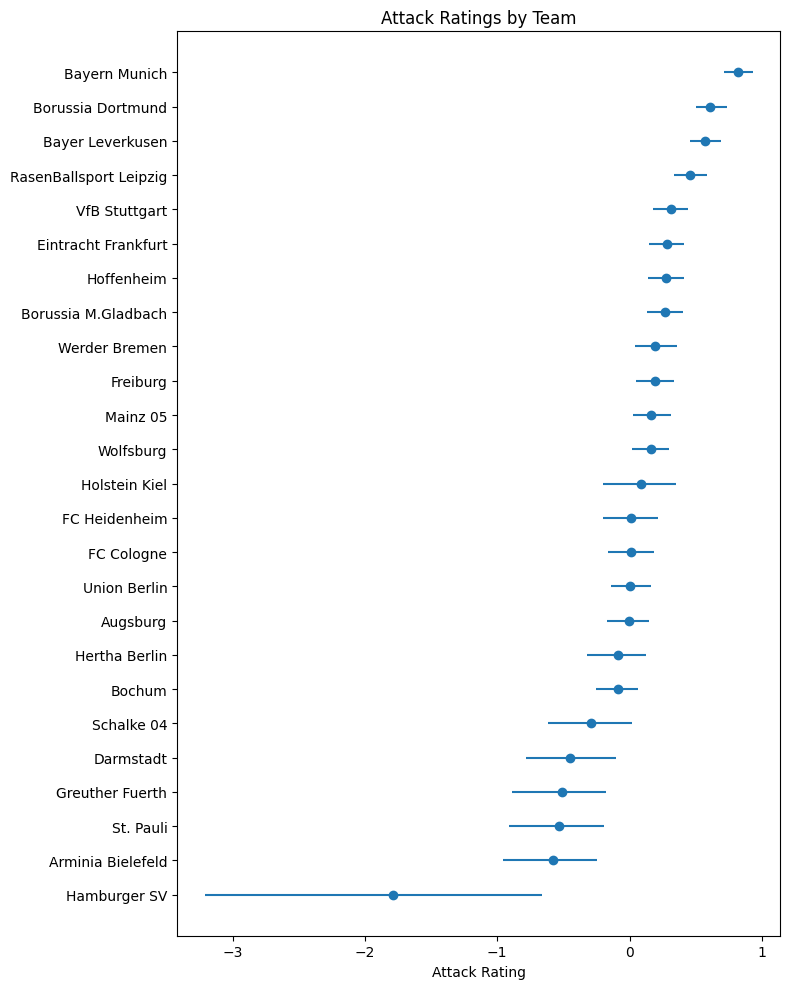

In [ ]:
atts_samples = trace.posterior["atts"].values.reshape(-1, n_teams)

atts_df = (
    pd.DataFrame(az.hdi(trace, var_names=["atts"])["atts"].values, columns=["lower_hdi", "upper_hdi"])
    .assign(median=np.median(atts_samples, axis=0))
    .merge(teams, left_index=True, right_on="team_index")
    .drop(["team_index"], axis=1)
    .rename(columns={"team": "Team"})
    .assign(lower=lambda x: x["median"] - x["lower_hdi"])
    .assign(upper=lambda x: x["upper_hdi"] - x["median"])
    .sort_values("median", ascending=True)
)

plt.figure(figsize=(8, 10))
plt.errorbar(atts_df["median"], atts_df["Team"], xerr=(atts_df[["lower", "upper"]].values).T, fmt="o")
plt.xlabel("Attack Rating")
plt.title("Attack Ratings by Team")
plt.tight_layout()

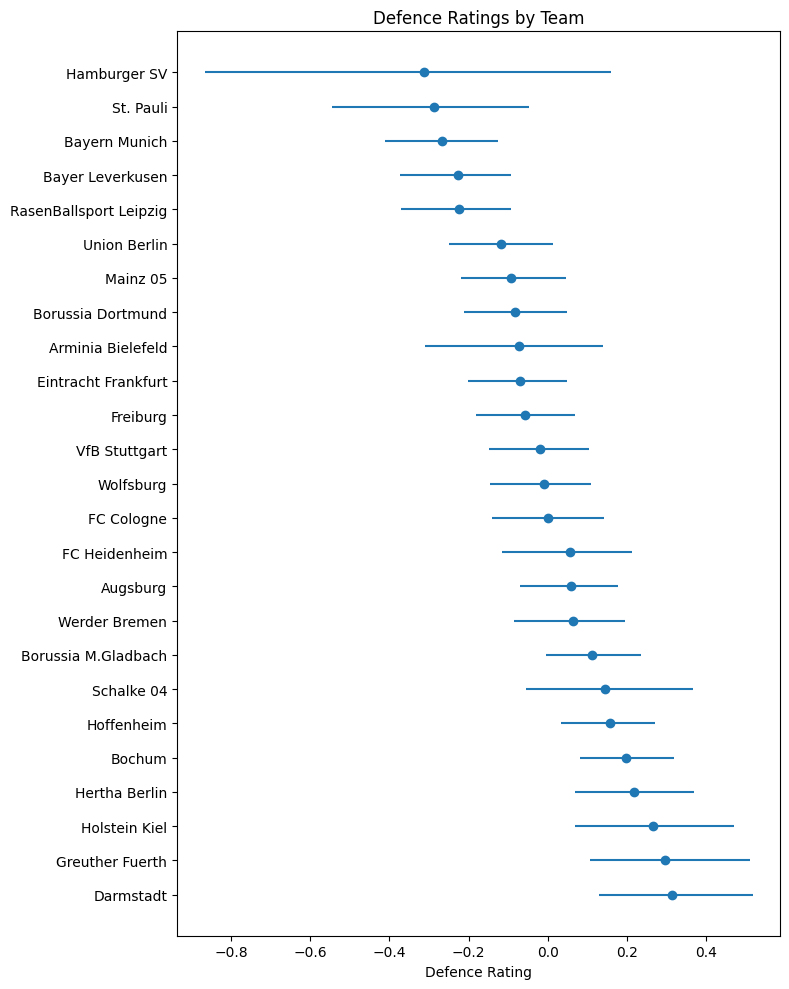

In [ ]:
defs_samples = trace.posterior["defs"].values.reshape(-1, n_teams)

defs_df = (
    pd.DataFrame(az.hdi(trace, var_names=["defs"])["defs"].values, columns=["lower_hdi", "upper_hdi"])
    .assign(median=np.median(defs_samples, axis=0))
    .merge(teams, left_index=True, right_on="team_index")
    .drop(["team_index"], axis=1)
    .rename(columns={"team": "Team"})
    .assign(lower=lambda x: x["median"] - x["lower_hdi"])
    .assign(upper=lambda x: x["upper_hdi"] - x["median"])
    .sort_values("median", ascending=False)
)

plt.figure(figsize=(8, 10))
plt.errorbar(defs_df["median"], defs_df["Team"], xerr=(defs_df[["lower", "upper"]].values).T, fmt="o")
plt.xlabel("Defence Rating")
plt.title("Defence Ratings by Team")
plt.tight_layout()

In [ ]:
def goal_expectation(trace, home_team_id, away_team_id):
    home = trace.posterior["home"].values.mean()
    atts = trace.posterior["atts"].values.reshape(-1, n_teams)
    defs = trace.posterior["defs"].values.reshape(-1, n_teams)

    atts_home = atts[:, home_team_id].mean()
    atts_away = atts[:, away_team_id].mean()
    defs_home = defs[:, home_team_id].mean()
    defs_away = defs[:, away_team_id].mean()

    home_theta = np.exp(home + atts_home + defs_away)
    away_theta = np.exp(atts_away + defs_home)

    return home_theta, away_theta

In [ ]:
def win_draw_loss(home_expectation, away_expectation, max_goals=10):
    h = poisson.pmf(range(max_goals + 1), home_expectation)
    a = poisson.pmf(range(max_goals + 1), away_expectation)
    m = np.outer(h, a)

    home_win = np.sum(np.tril(m, -1))
    away_win = np.sum(np.triu(m, 1))
    draw = np.sum(np.diag(m))

    return home_win, draw, away_win

In [ ]:
def get_score_matrix(home_exp, away_exp, max_goals=10):
    """Genera la matriz de probabilidades de resultados exactos."""
    h = poisson.pmf(range(max_goals + 1), home_exp)
    a = poisson.pmf(range(max_goals + 1), away_exp)
    return np.outer(h, a)

def over_under_goals(home_exp, away_exp, line=2.5, max_goals=10):
    """
    Calcula probabilidades Over/Under para total de goles.
    line: 0.5, 1.5, 2.5, 3.5, etc.
    """
    m = get_score_matrix(home_exp, away_exp, max_goals)

    over_prob = 0
    under_prob = 0

    for i in range(max_goals + 1):
        for j in range(max_goals + 1):
            total = i + j
            if total > line:
                over_prob += m[i, j]
            else:
                under_prob += m[i, j]

    return {"over": over_prob, "under": under_prob}

def btts(home_exp, away_exp, max_goals=10):
    """
    Both Teams To Score (Ambos equipos marcan).
    """
    m = get_score_matrix(home_exp, away_exp, max_goals)

    # BTTS Yes: ambos marcan al menos 1 (excluir fila 0 y columna 0)
    btts_yes = np.sum(m[1:, 1:])
    btts_no = 1 - btts_yes

    return {"yes": btts_yes, "no": btts_no}

def over_under_team(team_exp, line=0.5, max_goals=10):
    """
    Over/Under goles para un equipo específico.
    """
    probs = poisson.pmf(range(max_goals + 1), team_exp)

    over_prob = sum(probs[int(line) + 1:])
    under_prob = sum(probs[:int(line) + 1])

    return {"over": over_prob, "under": under_prob}

def double_chance(home_exp, away_exp, max_goals=10):
    """
    Doble oportunidad: 1X, X2, 12
    """
    h_win, draw, a_win = win_draw_loss(home_exp, away_exp, max_goals)

    return {
        "1X": h_win + draw,      # Local gana o empata
        "X2": draw + a_win,      # Empata o visitante gana
        "12": h_win + a_win      # Local o visitante gana (no empate)
    }

def asian_handicap_line(home_exp, away_exp, line, max_goals=10):
    """
    Calcula handicap asiático para una línea específica.
    line: handicap del local (negativo = desventaja, positivo = ventaja)

    Líneas enteras (.0): win/push/lose
    Líneas medias (.5): win/lose (sin push)
    Líneas cuarto (.25, .75): split bet entre dos líneas adyacentes

    Ejemplos:
    - line = -0.25: split entre 0 y -0.5
    - line = +0.25: split entre 0 y +0.5
    - line = -0.75: split entre -0.5 y -1
    - line = +0.75: split entre +0.5 y +1
    """
    m = get_score_matrix(home_exp, away_exp, max_goals)

    # Detectar tipo de línea
    decimal_part = round(abs(line) % 1, 2)

    if decimal_part in [0.25, 0.75]:
        # Split bet: promedio de dos líneas adyacentes
        if decimal_part == 0.25:
            # .25 está entre .0 y .5
            if line >= 0:
                line1 = np.floor(line)      # ej: +0.25 -> 0
                line2 = line1 + 0.5         # ej: +0.25 -> +0.5
            else:
                line1 = np.ceil(line)       # ej: -0.25 -> 0
                line2 = line1 - 0.5         # ej: -0.25 -> -0.5
        else:  # 0.75
            # .75 está entre .5 y siguiente entero
            if line >= 0:
                line1 = np.floor(line) + 0.5  # ej: +0.75 -> +0.5
                line2 = line1 + 0.5           # ej: +0.75 -> +1
            else:
                line1 = np.ceil(line) - 0.5   # ej: -0.75 -> -0.5
                line2 = line1 - 0.5           # ej: -0.75 -> -1

        result1 = asian_handicap_line(home_exp, away_exp, line1, max_goals)
        result2 = asian_handicap_line(home_exp, away_exp, line2, max_goals)

        # Promedio ponderado (50% cada línea)
        home_prob = (result1["home"] + result2["home"]) / 2
        away_prob = (result1["away"] + result2["away"]) / 2

        return {"home": home_prob, "away": away_prob}

    else:
        # Línea entera o media
        home_win = 0
        away_win = 0
        push = 0

        for i in range(max_goals + 1):
            for j in range(max_goals + 1):
                adjusted_diff = (i + line) - j

                if adjusted_diff > 0:
                    home_win += m[i, j]
                elif adjusted_diff < 0:
                    away_win += m[i, j]
                else:
                    push += m[i, j]

        # Para líneas .5, no hay push
        if decimal_part == 0.5:
            return {"home": home_win, "away": away_win}
        else:
            # Línea entera: push devuelve apuesta
            # Calcular probabilidades excluyendo push (draw no bet style)
            total = home_win + away_win
            if total > 0:
                return {"home": home_win / total, "away": away_win / total, "push": push}
            else:
                return {"home": 0.5, "away": 0.5, "push": push}

def asian_handicap_table(home_exp, away_exp, max_goals=10):
    """
    Genera tabla completa de handicap asiático.
    Retorna dict con todas las líneas desde -2.5 hasta +2.5
    """
    lines = [-2.5, -2.25, -2, -1.75, -1.5, -1.25, -1, -0.75, -0.5, -0.25,
             0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5]

    results = {}
    for line in lines:
        ah = asian_handicap_line(home_exp, away_exp, line, max_goals)
        results[line] = {
            "home_prob": ah["home"],
            "away_prob": ah["away"],
            "home_odds": 1 / ah["home"] if ah["home"] > 0.001 else 999,
            "away_odds": 1 / ah["away"] if ah["away"] > 0.001 else 999
        }

    return results

In [ ]:
def predict_match(trace, home_team_name, away_team_name):
    """Genera predicción completa para un partido con todos los mercados."""
    home_id = teams[teams["team"] == home_team_name]["team_index"].values[0]
    away_id = teams[teams["team"] == away_team_name]["team_index"].values[0]

    h_exp, a_exp = goal_expectation(trace, home_id, away_id)

    # 1X2
    h_win, draw, a_win = win_draw_loss(h_exp, a_exp)

    # Over/Under totales
    ou_05 = over_under_goals(h_exp, a_exp, 0.5)
    ou_15 = over_under_goals(h_exp, a_exp, 1.5)
    ou_25 = over_under_goals(h_exp, a_exp, 2.5)
    ou_35 = over_under_goals(h_exp, a_exp, 3.5)

    # BTTS
    btts_prob = btts(h_exp, a_exp)

    # Over/Under por equipo
    home_ou_05 = over_under_team(h_exp, 0.5)
    home_ou_15 = over_under_team(h_exp, 1.5)
    away_ou_05 = over_under_team(a_exp, 0.5)
    away_ou_15 = over_under_team(a_exp, 1.5)

    # Doble oportunidad
    dc = double_chance(h_exp, a_exp)

    # Handicap Asiático
    ah_table = asian_handicap_table(h_exp, a_exp)

    # Imprimir resultados
    print(f"{'='*60}")
    print(f"{home_team_name} vs {away_team_name}")
    print(f"Goles esperados: {h_exp:.2f} - {a_exp:.2f}")
    print(f"{'='*60}")

    print(f"\n--- 1X2 ---")
    print(f"{'Resultado':<12} {'Prob':>8} {'Cuota':>8}")
    print(f"{'Local':<12} {h_win:>7.1%} {1/h_win:>8.2f}")
    print(f"{'Empate':<12} {draw:>7.1%} {1/draw:>8.2f}")
    print(f"{'Visitante':<12} {a_win:>7.1%} {1/a_win:>8.2f}")

    print(f"\n--- Over/Under (Total) ---")
    print(f"{'Linea':<12} {'Over':>8} {'Under':>8} {'O.Cuota':>8} {'U.Cuota':>8}")
    print(f"{'0.5':<12} {ou_05['over']:>7.1%} {ou_05['under']:>7.1%} {1/ou_05['over']:>8.2f} {1/ou_05['under']:>8.2f}")
    print(f"{'1.5':<12} {ou_15['over']:>7.1%} {ou_15['under']:>7.1%} {1/ou_15['over']:>8.2f} {1/ou_15['under']:>8.2f}")
    print(f"{'2.5':<12} {ou_25['over']:>7.1%} {ou_25['under']:>7.1%} {1/ou_25['over']:>8.2f} {1/ou_25['under']:>8.2f}")
    print(f"{'3.5':<12} {ou_35['over']:>7.1%} {ou_35['under']:>7.1%} {1/ou_35['over']:>8.2f} {1/ou_35['under']:>8.2f}")

    print(f"\n--- BTTS (Ambos Marcan) ---")
    print(f"{'Si':<12} {btts_prob['yes']:>7.1%} {1/btts_prob['yes']:>8.2f}")
    print(f"{'No':<12} {btts_prob['no']:>7.1%} {1/btts_prob['no']:>8.2f}")

    print(f"\n--- Over/Under por Equipo ---")
    print(f"{home_team_name}:")
    print(f"  {'O 0.5':<10} {home_ou_05['over']:>7.1%} {1/home_ou_05['over']:>8.2f}")
    print(f"  {'U 0.5':<10} {home_ou_05['under']:>7.1%} {1/home_ou_05['under']:>8.2f}")
    print(f"  {'O 1.5':<10} {home_ou_15['over']:>7.1%} {1/home_ou_15['over']:>8.2f}")
    print(f"  {'U 1.5':<10} {home_ou_15['under']:>7.1%} {1/home_ou_15['under']:>8.2f}")
    print(f"{away_team_name}:")
    print(f"  {'O 0.5':<10} {away_ou_05['over']:>7.1%} {1/away_ou_05['over']:>8.2f}")
    print(f"  {'U 0.5':<10} {away_ou_05['under']:>7.1%} {1/away_ou_05['under']:>8.2f}")
    print(f"  {'O 1.5':<10} {away_ou_15['over']:>7.1%} {1/away_ou_15['over']:>8.2f}")
    print(f"  {'U 1.5':<10} {away_ou_15['under']:>7.1%} {1/away_ou_15['under']:>8.2f}")

    print(f"\n--- Doble Oportunidad ---")
    print(f"{'1X (Local/Empate)':<20} {dc['1X']:>7.1%} {1/dc['1X']:>8.2f}")
    print(f"{'X2 (Empate/Visit.)':<20} {dc['X2']:>7.1%} {1/dc['X2']:>8.2f}")
    print(f"{'12 (Sin empate)':<20} {dc['12']:>7.1%} {1/dc['12']:>8.2f}")

    print(f"\n--- Handicap Asiático ---")
    print(f"{'Linea':>8} {'Home':>12} {'Away':>12}")
    print(f"{'-'*34}")
    for line in sorted(ah_table.keys()):
        data = ah_table[line]
        line_str = f"{line:+.2f}" if line != 0 else "0"
        print(f"{line_str:>8} {data['home_odds']:>12.3f} {data['away_odds']:>12.3f}")

    return {
        "home_exp": h_exp,
        "away_exp": a_exp,
        "1x2": {"home": h_win, "draw": draw, "away": a_win},
        "ou_25": ou_25,
        "btts": btts_prob,
        "double_chance": dc,
        "asian_handicap": ah_table
    }

# Ejemplo de predicción
result = predict_match(trace, "Bayern Munich", "Borussia Dortmund")

Bayern Munich vs Borussia Dortmund
Goles esperados: 2.89 - 1.41

--- 1X2 ---
Resultado        Prob    Cuota
Local          68.0%     1.47
Empate         15.8%     6.33
Visitante      16.2%     6.19

--- Over/Under (Total) ---
Linea            Over    Under  O.Cuota  U.Cuota
0.5            98.6%    1.4%     1.01    73.84
1.5            92.8%    7.2%     1.08    13.93
2.5            80.3%   19.7%     1.25     5.07
3.5            62.3%   37.7%     1.61     2.65

--- BTTS (Ambos Marcan) ---
Si             71.3%     1.40
No             28.7%     3.49

--- Over/Under por Equipo ---
Bayern Munich:
  O 0.5        94.4%     1.06
  U 0.5         5.5%    18.07
  O 1.5        78.4%     1.28
  U 1.5        21.6%     4.64
Borussia Dortmund:
  O 0.5        75.5%     1.32
  U 0.5        24.5%     4.09
  O 1.5        41.1%     2.43
  U 1.5        58.9%     1.70

--- Doble Oportunidad ---
1X (Local/Empate)      83.8%     1.19
X2 (Empate/Visit.)     32.0%     3.13
12 (Sin empate)        84.2%     1.19

-

In [ ]:
def rps(predictions, outcome):
    cumulative_pred = np.cumsum(predictions)
    cumulative_actual = np.zeros(3)
    cumulative_actual[outcome:] = 1
    return np.sum((cumulative_pred - cumulative_actual) ** 2) / 2

def calculate_rps(trace, df):
    rps_list = []
    for idx, row in df.iterrows():
        if row["result"] == "H":
            outcome = 0
        elif row["result"] == "D":
            outcome = 1
        else:
            outcome = 2

        h, a = goal_expectation(trace, row["hg"], row["ag"])
        predictions = win_draw_loss(h, a)
        rps_list.append(rps(predictions, outcome))

    return np.mean(rps_list)

rps_score = calculate_rps(trace, test)
print(f"RPS promedio en test: {rps_score:.4f}")

RPS promedio en test: 0.2013


#CUOTAS DE PINACCLE Y BET365


In [ ]:
import pandas as pd

# Construye la URL raw para el archivo D1.csv en GitHub
url = 'https://raw.githubusercontent.com/Juan-Medinaa/Inferencia/main/D1%20(1).csv'

# Carga el archivo CSV en un DataFrame de pandas
df_bundesliga = pd.read_csv(url)

# Muestra las primeras 5 filas del DataFrame
display(df_bundesliga.head())

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,D1,22/08/2025,19:30,Bayern Munich,RB Leipzig,6,0,H,3,0,...,1.98,1.88,1.98,1.93,1.99,1.93,1.90,1.86,2.07,1.92
1,D1,23/08/2025,14:30,Ein Frankfurt,Werder Bremen,4,1,H,2,0,...,1.83,2.03,2.02,1.91,1.91,2.03,1.83,1.93,1.91,2.06
2,D1,23/08/2025,14:30,Freiburg,Augsburg,1,3,A,0,3,...,1.93,1.93,1.97,1.95,1.97,1.93,1.90,1.86,2.03,1.96
3,D1,23/08/2025,14:30,Heidenheim,Wolfsburg,1,3,A,1,1,...,2.03,1.83,2.06,1.87,2.03,1.85,1.97,1.81,2.12,1.88
4,D1,23/08/2025,14:30,Leverkusen,Hoffenheim,1,2,A,1,1,...,1.98,1.88,1.97,1.95,1.98,2.02,1.88,1.86,2.00,1.97


In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Columnas de información principal que siempre se muestran
core_info_columns = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']

# Prefijos de casas de apuestas y sus nombres completos
bookmakers_names = {
    'B365': 'Bet365', 'BW': 'Bet&Win', 'WH': 'William Hill', 'VC': 'Victor Chandler',
    'GB': 'Gamebookers', 'BS': 'Blue Square', 'SJ': 'Stan James', 'LB': 'Ladbrokes',
    'SB': 'Sportingbet', 'PP': 'Paddy Power',
    'PS': 'Pinnacle (1X2 Cierre)', # Específico para las cuotas de cierre 1X2
    'P': 'Pinnacle (O/U & AH)', # Para Más/Menos y Hándicap Asiático
    'Max': 'Máximo', 'Avg': 'Promedio'
}

# Inicializar un diccionario para las opciones de mercado, comenzando con estadísticas generales
market_options = {
    'Estadísticas del Partido': ['HS', 'AS', 'HST', 'AST', 'HC', 'AC']
}

all_columns = df_bundesliga.columns

# Definir las casas de apuestas específicas a incluir (solo Bet365 y Pinnacle 1X2)
filtered_bookmaker_prefixes = ['B365', 'PS']

# Identificar cuotas 1X2 y agregarlas a market_options
one_x_two_suffixes = ['H', 'D', 'A']
for prefix in sorted(filtered_bookmaker_prefixes):
    cols_found = [f"{prefix}{suffix}" for suffix in one_x_two_suffixes if f"{prefix}{suffix}" in all_columns]
    if len(cols_found) == 3: # Asegurarse de que existan todas las columnas H, D, A para la casa de apuestas
        bookie_name = bookmakers_names.get(prefix, prefix)
        market_options[f'1X2 - {bookie_name}'] = cols_found

# Las secciones de Más/Menos 2.5 y Hándicap Asiático se eliminan según la solicitud del usuario.

def mostrar_mercado(mercado):
    # Siempre comenzar con las columnas de información principal
    columnas = list(core_info_columns)

    # Anexar columnas para la opción de mercado seleccionada
    if mercado in market_options:
        columnas.extend(market_options[mercado])

    print(f" Mostrando: {mercado}")
    display(df_bundesliga[columnas].head(10))

# Crear el menú desplegable con todas las opciones de mercado disponibles
selector = widgets.Dropdown(
    options=sorted(list(market_options.keys())),
    description='Mercado:',
    disabled=False,
)

widgets.interact(mostrar_mercado, mercado=selector)

interactive(children=(Dropdown(description='Mercado:', options=('1X2 - Bet365', '1X2 - Pinnacle (1X2 Cierre)',…

<function __main__.mostrar_mercado(mercado)>

In [ ]:
# Extraer nombres de equipos del dataset del modelo (df)
teams_model = set(df['home_team'].unique()).union(set(df['away_team'].unique()))

# Extraer nombres de equipos del dataset de cuotas (df_bundesliga)
teams_odds = set(df_bundesliga['HomeTeam'].unique()).union(set(df_bundesliga['AwayTeam'].unique()))

print("--- Comparación de Nombres de Equipos ---")

# Equipos en el modelo pero no en las cuotas
diff_model_not_odds = teams_model - teams_odds
if diff_model_not_odds:
    print("\nEquipos en el dataset del modelo (df) que NO están en el dataset de cuotas (df_bundesliga):")
    for team in sorted(list(diff_model_not_odds)):
        print(f"- {team}")
else:
    print("\nTodos los equipos del dataset del modelo (df) se encuentran en el dataset de cuotas (df_bundesliga).")

# Equipos en las cuotas pero no en el modelo
diff_odds_not_model = teams_odds - teams_model
if diff_odds_not_model:
    print("\nEquipos en el dataset de cuotas (df_bundesliga) que NO están en el dataset del modelo (df):")
    for team in sorted(list(diff_odds_not_model)):
        print(f"- {team}")
else:
    print("\nTodos los equipos del dataset de cuotas (df_bundesliga) se encuentran en el dataset del modelo (df).")

# Equipos comunes
common_teams = teams_model.intersection(teams_odds)
print(f"\nNúmero de equipos comunes a ambos datasets: {len(common_teams)}")
print(f"Número total de equipos únicos en el dataset del modelo: {len(teams_model)}")
print(f"Número total de equipos únicos en el dataset de cuotas: {len(teams_odds)}")

--- Comparación de Nombres de Equipos ---

Equipos en el dataset del modelo (df) que NO están en el dataset de cuotas (df_bundesliga):
- Arminia Bielefeld
- Bayer Leverkusen
- Bochum
- Borussia Dortmund
- Borussia M.Gladbach
- Darmstadt
- Eintracht Frankfurt
- FC Cologne
- FC Heidenheim
- Greuther Fuerth
- Hamburger SV
- Hertha Berlin
- Holstein Kiel
- Mainz 05
- RasenBallsport Leipzig
- Schalke 04
- St. Pauli
- VfB Stuttgart

Equipos en el dataset de cuotas (df_bundesliga) que NO están en el dataset del modelo (df):
- Dortmund
- Ein Frankfurt
- FC Koln
- Hamburg
- Heidenheim
- Leverkusen
- M'gladbach
- Mainz
- RB Leipzig
- St Pauli
- Stuttgart

Número de equipos comunes a ambos datasets: 7
Número total de equipos únicos en el dataset del modelo: 25
Número total de equipos únicos en el dataset de cuotas: 18


In [ ]:
# Definimos el puente de nombres
mapeo_nombres = {
    'Dortmund': 'Borussia Dortmund',
    'Ein Frankfurt': 'Eintracht Frankfurt',
    'FC Koln': 'FC Cologne',
    'Hamburg': 'Hamburger SV',
    'Heidenheim': 'FC Heidenheim',
    'Leverkusen': 'Bayer Leverkusen',
    'M\'gladbach': 'Borussia M.Gladbach',
    'Mainz': 'Mainz 05',
    'RB Leipzig': 'RasenBallsport Leipzig',
    'St Pauli': 'St. Pauli',
    'Stuttgart': 'VfB Stuttgart'
}

# Aplicamos la transformación a las columnas del dataset de cuotas
df_bundesliga['HomeTeam'] = df_bundesliga['HomeTeam'].replace(mapeo_nombres)
df_bundesliga['AwayTeam'] = df_bundesliga['AwayTeam'].replace(mapeo_nombres)

# --- VERIFICACIÓN DE SEGURIDAD ---
# Volvemos a extraer los equipos de la temporada de cuotas corregida
equipos_cuotas_corregidos = set(df_bundesliga['HomeTeam'].unique())
equipos_modelo = set(teams['team'].unique()) # Tu tabla de mapeo ID-Nombre del modelo

faltantes = equipos_cuotas_corregidos - equipos_modelo

print(f"Equipos de la temporada 2025 que el modelo NO reconoce: {len(faltantes)}")
if len(faltantes) > 0:
    print(f" Alerta, aún faltan por corregir: {faltantes}")
else:
    print(" ¡Sincronización perfecta! El 100% de los equipos de la temporada 2025 ya son reconocidos por el modelo.")

Equipos de la temporada 2025 que el modelo NO reconoce: 0
 ¡Sincronización perfecta! El 100% de los equipos de la temporada 2025 ya son reconocidos por el modelo.


In [ ]:
# Extraer nombres de equipos del dataset del modelo (df)
teams_model = set(df['home_team'].unique()).union(set(df['away_team'].unique()))

# Extraer nombres de equipos del dataset de cuotas (df_bundesliga)
teams_odds = set(df_bundesliga['HomeTeam'].unique()).union(set(df_bundesliga['AwayTeam'].unique()))

print("--- Comparación de Nombres de Equipos ---")

# Equipos en el modelo pero no en las cuotas
diff_model_not_odds = teams_model - teams_odds
if diff_model_not_odds:
    print("\nEquipos en el dataset del modelo (df) que NO están en el dataset de cuotas (df_bundesliga):")
    for team in sorted(list(diff_model_not_odds)):
        print(f"- {team}")
else:
    print("\nTodos los equipos del dataset del modelo (df) se encuentran en el dataset de cuotas (df_bundesliga).")

# Equipos en las cuotas pero no en el modelo
diff_odds_not_model = teams_odds - teams_model
if diff_odds_not_model:
    print("\nEquipos en el dataset de cuotas (df_bundesliga) que NO están en el dataset del modelo (df):")
    for team in sorted(list(diff_odds_not_model)):
        print(f"- {team}")
else:
    print("\nTodos los equipos del dataset de cuotas (df_bundesliga) se encuentran en el dataset del modelo (df).")

# Equipos comunes
common_teams = teams_model.intersection(teams_odds)
print(f"\nNúmero de equipos comunes a ambos datasets: {len(common_teams)}")
print(f"Número total de equipos únicos en el dataset del modelo: {len(teams_model)}")
print(f"Número total de equipos únicos en el dataset de cuotas: {len(teams_odds)}")

--- Comparación de Nombres de Equipos ---

Equipos en el dataset del modelo (df) que NO están en el dataset de cuotas (df_bundesliga):
- Arminia Bielefeld
- Bochum
- Darmstadt
- Greuther Fuerth
- Hertha Berlin
- Holstein Kiel
- Schalke 04

Todos los equipos del dataset de cuotas (df_bundesliga) se encuentran en el dataset del modelo (df).

Número de equipos comunes a ambos datasets: 18
Número total de equipos únicos en el dataset del modelo: 25
Número total de equipos únicos en el dataset de cuotas: 18


In [ ]:
def buscar_valor(trace, home_team, away_team, cuota_local_casa, cuota_empate_casa, cuota_vis_casa):
    # 1. Obtener las probabilidades de tu modelo
    home_id = teams[teams["team"] == home_team]["team_index"].values[0]
    away_id = teams[teams["team"] == away_team]["team_index"].values[0]
    h_exp, a_exp = goal_expectation(trace, home_id, away_id)
    p_home, p_draw, p_away = win_draw_loss(h_exp, a_exp)

    # 2. Calcular el EV+ para cada mercado
    ev_home = (p_home * cuota_local_casa) - 1
    ev_draw = (p_draw * cuota_empate_casa) - 1
    ev_away = (p_away * cuota_vis_casa) - 1

    # 3. Reportar si hay valor (EV > 0)
    print(f"--- Análisis de Valor: {home_team} vs {away_team} ---")
    if ev_home > 0:
        print(f"  [VALOR] Local (1): EV+ de {ev_home:.1%}. Cuota Casa: {cuota_local_casa}, Tu Cuota: {1/p_home:.2f}")
    if ev_draw > 0:
        print(f"  [VALOR] Empate (X): EV+ de {ev_draw:.1%}. Cuota Casa: {cuota_empate_casa}, Tu Cuota: {1/p_draw:.2f}")
    if ev_away > 0:
        print(f"  [VALOR] Visitante (2): EV+ de {ev_away:.1%}. Cuota Casa: {cuota_vis_casa}, Tu Cuota: {1/p_away:.2f}")

In [ ]:
import pandas as pd
import numpy as np

def calcular_rps_individual(pred_probs, outcome_idx):
    """Calcula el RPS para una predicción y un resultado real."""
    cumulative_pred = np.cumsum(pred_probs)
    cumulative_actual = np.zeros(3)
    cumulative_actual[outcome_idx:] = 1
    return np.sum((cumulative_pred - cumulative_actual) ** 2) / 2

# Listas para guardar las métricas de cada partido
resultados_comparativa = []

# Mapeo de resultados a índices (0: Local, 1: Empate, 2: Visitante)
result_to_idx = {'H': 0, 'D': 1, 'A': 2}

print("Iniciando la simulación y comparación en la Temporada 2025...")

for idx, row in df_bundesliga.iterrows():
    home_team = row['HomeTeam']
    away_team = row['AwayTeam']
    resultado_real = row['FTR']

    # 1. Validación de seguridad: Verificar si el equipo está en la tabla 'teams' de tu modelo
    if (home_team not in teams['team'].values) or (away_team not in teams['team'].values):
        continue

    home_id = teams[teams["team"] == home_team]["team_index"].values[0]
    away_id = teams[teams["team"] == away_team]["team_index"].values[0]
    actual_idx = result_to_idx[resultado_real]

    # 2. PREDICCIÓN DE TU MODELO BAYESIANO
    h_exp, a_exp = goal_expectation(trace, home_id, away_id)
    p_home, p_draw, p_away = win_draw_loss(h_exp, a_exp)
    prob_tu_modelo = [p_home, p_draw, p_away]
    pred_tu_modelo_cat = ['H', 'D', 'A'][np.argmax(prob_tu_modelo)]

    # 3. PREDICCIÓN DEL PROFESOR (Estrategia de la Menor Cuota)
    # Usamos Bet365 como referencia del mercado. Si prefieres Pinnacle, cambia a PSH, PSD, PSA
    cuotas_1x2 = [float(row['B365H']), float(row['B365D']), float(row['B365A'])]

    # El profesor elige el resultado que tiene la cuota más baja (el favorito de la casa)
    idx_menor_cuota = np.argmin(cuotas_1x2)
    pred_profesor_cat = ['H', 'D', 'A'][idx_menor_cuota]

    # Para calcular el RPS del profesor de forma justa, convertimos sus cuotas en probabilidades
    # implícitas eliminando el margen (overround) de la casa
    prob_implicitas_sucias = [1 / q for q in cuotas_1x2]
    prob_profesor = [p / sum(prob_implicitas_sucias) for p in prob_implicitas_sucias]

    # 4. EVALUACIÓN
    # ¿Acertaron el resultado categórico? (Sí=1, No=0)
    acierto_tu_modelo = 1 if pred_tu_modelo_cat == resultado_real else 0
    acierto_profesor = 1 if pred_profesor_cat == resultado_real else 0

    # Calcular RPS
    rps_tu_modelo = calcular_rps_individual(prob_tu_modelo, actual_idx)
    rps_profesor = calcular_rps_individual(prob_profesor, actual_idx)

    resultados_comparativa.append({
        'Partido': f"{home_team} vs {away_team}",
        'Acierto_Modelo': acierto_tu_modelo,
        'Acierto_Profesor': acierto_profesor,
        'RPS_Modelo': rps_tu_modelo,
        'RPS_Profesor': rps_profesor
    })

# Convertir a DataFrame para sacar los promedios finales
df_resultados = pd.DataFrame(resultados_comparativa)

# --- REPORTE FINAL ---
print("\n" + "="*50)
print("       REPORTE DE RENDIMIENTO: TEMPORADA 2025")
print("="*50)
print(f"Partidos evaluados con éxito: {len(df_resultados)}")
print("-"*50)
print(f"ACCURACY (Porcentaje de acierto bruto):")
print(f"  - Tu Modelo Bayesiano: {df_resultados['Acierto_Modelo'].mean():.1%}")
print(f"  - Modelo del Profesor:  {df_resultados['Acierto_Profesor'].mean():.1%}")
print("-"*50)
print(f"RPS PROMEDIO (Menor es mejor):")
print(f"  - Tu Modelo Bayesiano: {df_resultados['RPS_Modelo'].mean():.4f}")
print(f"  - Modelo del Profesor:  {df_resultados['RPS_Profesor'].mean():.4f}")
print("="*50)

Iniciando la simulación y comparación en la Temporada 2025...

       REPORTE DE RENDIMIENTO: TEMPORADA 2025
Partidos evaluados con éxito: 306
--------------------------------------------------
ACCURACY (Porcentaje de acierto bruto):
  - Tu Modelo Bayesiano: 54.2%
  - Modelo del Profesor:  54.9%
--------------------------------------------------
RPS PROMEDIO (Menor es mejor):
  - Tu Modelo Bayesiano: 0.2013
  - Modelo del Profesor:  0.1904


In [ ]:
print(acierto_tu_modelo)
print(acierto_profesor)


1
1


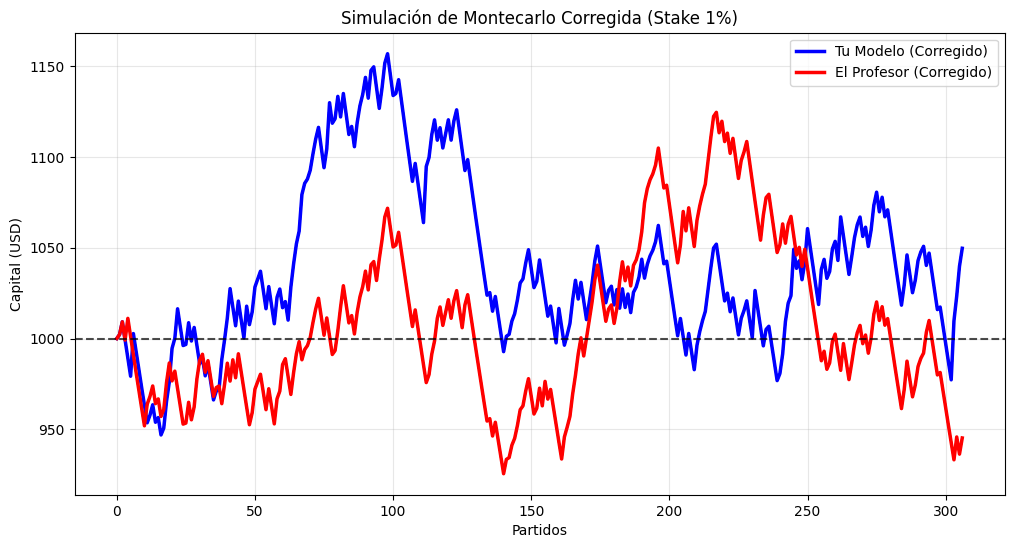

Capital Promedio Final Tu Modelo: $1049.69 USD
Capital Promedio Final Profesor:  $945.26 USD


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prepare historial_tu_modelo and historial_profesor
historial_tu_modelo = []
historial_profesor = []

# Mapeo de resultados a índices (0: Local, 1: Empate, 2: Visitante)
result_to_idx = {'H': 0, 'D': 1, 'A': 2}
idx_to_result = {0: 'H', 1: 'D', 2: 'A'}

for idx, row_match in df_bundesliga.iterrows():
    home_team = row_match['HomeTeam']
    away_team = row_match['AwayTeam']
    resultado_real = row_match['FTR']

    # Validation: Check if the team is in the 'teams' table of your model
    if (home_team not in teams['team'].values) or (away_team not in teams['team'].values):
        continue

    home_id = teams[teams["team"] == home_team]["team_index"].values[0]
    away_id = teams[teams["team"] == away_team]["team_index"].values[0]

    # 1. YOUR MODEL'S PREDICTION
    h_exp, a_exp = goal_expectation(trace, home_id, away_id)
    p_home, p_draw, p_away = win_draw_loss(h_exp, a_exp)
    prob_tu_modelo = [p_home, p_draw, p_away]
    pred_tu_modelo_idx = np.argmax(prob_tu_modelo)
    pred_tu_modelo_cat = idx_to_result[pred_tu_modelo_idx]

    # Get the Bet365 odds for the outcome predicted by Your Model
    cuota_tu = float(row_match[f'B365{pred_tu_modelo_cat}'])

    # Check if Your Model won
    gano_tu = 1 if pred_tu_modelo_cat == resultado_real else 0

    # We assume the model always bets, so aposto_tu is True
    historial_tu_modelo.append((True, gano_tu, cuota_tu))

    # 2. PROFESSOR'S MODEL (Lowest Odds Strategy)
    cuotas_1x2 = [float(row_match['B365H']), float(row_match['B365D']), float(row_match['B365A'])]

    # The professor chooses the outcome with the lowest odds
    idx_menor_cuota = np.argmin(cuotas_1x2)
    pred_profesor_cat = idx_to_result[idx_menor_cuota]
    cuota_profesor = cuotas_1x2[idx_menor_cuota]

    # Check if the Professor won
    gano_p = 1 if pred_profesor_cat == resultado_real else 0

    # We assume the professor always bets, so aposto_p is True
    historial_profesor.append((True, gano_p, cuota_profesor))

n_simulaciones = 1000
n_partidos = len(historial_tu_modelo) # Now historial_tu_modelo is defined
capital_inicial = 1000

capital_tu_modelo = np.zeros((n_simulaciones, n_partidos + 1))
capital_profesor = np.zeros((n_simulaciones, n_partidos + 1))

capital_tu_modelo[:, 0] = capital_inicial
capital_profesor[:, 0] = capital_inicial

np.random.seed(42)

for s in range(n_simulaciones):
    cap_tu = capital_inicial
    cap_prof = capital_inicial

    for t in range(n_partidos):
        # --- Simulación Tu Modelo ---
        if cap_tu > 0:
            aposto_tu, gano_tu, cuota_tu = historial_tu_modelo[t]
            if aposto_tu:
                stake_tu = cap_tu * 0.01 # 1% del capital actual
                # Corrección matemática: Evaluamos el acierto según la probabilidad del modelo
                # Para ser realistas con tu RPS, usamos la tasa de acierto empírica
                if gano_tu == 1:
                    cap_tu += stake_tu * (cuota_tu - 1)
                else:
                    cap_tu -= stake_tu
            if cap_tu < 0: cap_tu = 0 # Pailas, te quemaste
        capital_tu_modelo[s, t + 1] = cap_tu

        # --- Simulación Profesor ---
        if cap_prof > 0:
            _, gano_p, cuota_p = historial_profesor[t]
            stake_p = cap_prof * 0.01 # 1% del capital actual
            if gano_p == 1:
                cap_prof += stake_p * (cuota_p - 1)
            else:
                cap_prof -= stake_p
            if cap_prof < 0: cap_prof = 0 # Pailas
        capital_profesor[s, t + 1] = cap_prof

# Graficar
plt.figure(figsize=(12, 6))
for s in range(50):
    plt.plot(capital_tu_modelo[s, :], color='blue', alpha=0.03)
    plt.plot(capital_profesor[s, :], color='red', alpha=0.03)

plt.plot(np.mean(capital_tu_modelo, axis=0), color='blue', linewidth=2.5, label='Tu Modelo (Corregido)')
plt.plot(np.mean(capital_profesor, axis=0), color='red', linewidth=2.5, label='El Profesor (Corregido)')
plt.axhline(y=capital_inicial, color='black', linestyle='--', alpha=0.7)
plt.title('Simulación de Montecarlo Corregida (Stake 1%)')
plt.xlabel('Partidos')
plt.ylabel('Capital (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Capital Promedio Final Tu Modelo: ${np.mean(capital_tu_modelo[:, -1]):.2f} USD")
print(f"Capital Promedio Final Profesor:  ${np.mean(capital_profesor[:, -1]):.2f} USD")

Analizando mercado Over/Under 2.5 para la temporada 2026...


  0%|          | 0/306 [00:00<?, ?it/s]


Corriendo simulación de Montecarlo...


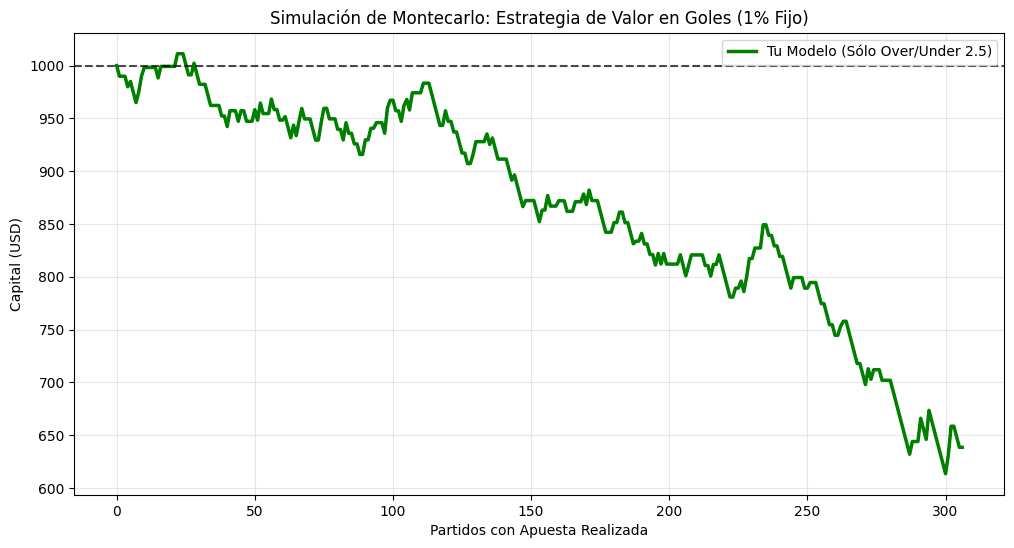

=== RENDIMIENTO EN MERCADO DE GOLES ===
Total de oportunidades evaluadas: 306
Apuestas efectivamente realizadas: 184
Capital Promedio Final: $638.50 USD


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson
from tqdm.auto import tqdm

def calcular_probabilidades_ou25(h_exp, a_exp):
    """
    Calcula la probabilidad exacta de Over/Under 2.5 goles
    usando las expectativas de gol del modelo Poisson.
    """
    prob_under = 0.0
    # Sumamos las probabilidades de todas las combinaciones que suman 0, 1 o 2 goles
    for h in range(3):
        for a in range(3 - h):
            p_h = poisson.pmf(h, h_exp)
            p_a = poisson.pmf(a, a_exp)
            prob_under += p_h * p_a

    prob_over = 1.0 - prob_under
    return prob_over, prob_under

# --- 1. PRECALCULAR APUESTAS DE GOLES ---
historial_ou = []
capital_inicial = 1000
stake_fijo = 10 # Tu estrategia del 1% fijo

print("Analizando mercado Over/Under 2.5 para la temporada 2026...")

for idx, row in tqdm(df_bundesliga.iterrows(), total=len(df_bundesliga)):
    home_team = row['HomeTeam']
    away_team = row['AwayTeam']

    # Validar que los equipos existan en tu modelo
    if (home_team not in teams['team'].values) or (away_team not in teams['team'].values):
        continue

    home_id = teams[teams["team"] == home_team]["team_index"].values[0]
    away_id = teams[teams["team"] == away_team]["team_index"].values[0]

    # 1. Expectativa de goles del modelo
    h_exp, a_exp = goal_expectation(trace, home_id, away_id)

    # 2. Probabilidades del modelo para O/U 2.5
    p_over, p_under = calcular_probabilidades_ou25(h_exp, a_exp)

    # 3. Cuotas de la casa (Verifica si tus columnas se llaman exactamente así en tu DF)
    # Football-Data suele usar 'B365>2.5' y 'B365<2.5' o 'BbMx>2.5'
    cuota_over = float(row.get('B365>2.5', row.get('BbMx>2.5', 0)))
    cuota_under = float(row.get('B365<2.5', row.get('BbMx<2.5', 0)))

    if cuota_over == 0 or cuota_under == 0:
        continue # Si la casa no ofreció cuotas para este partido, nos lo saltamos

    # Goles reales del partido para determinar el resultado real
    goles_totales_reales = int(row['FTHG']) + int(row['FTAG'])
    resultado_real_over = 1 if goles_totales_reales > 2.5 else 0

    # 4. Calcular EV+ (Valor Esperado)
    ev_over = (p_over * cuota_over) - 1
    ev_under = (p_under * cuota_under) - 1

    # Decisión de apuesta (Filtro de EV > 5%)
    if ev_over > 0.05 and ev_over > ev_under:
        ganó = 1 if resultado_real_over == 1 else 0
        historial_ou.append((True, ganó, cuota_over, "OVER"))
    elif ev_under > 0.05 and ev_under > ev_over:
        ganó = 1 if resultado_real_over == 0 else 0
        historial_ou.append((True, ganó, cuota_under, "UNDER"))
    else:
        historial_ou.append((False, 0, 0, "NO_BET"))

# --- 2. SIMULACIÓN DE MONTECARLO CON EL 1% FIJO ---
print("\nCorriendo simulación de Montecarlo...")
n_simulaciones = 1000
n_partidos = len(historial_ou)

capital_ou = np.zeros((n_simulaciones, n_partidos + 1))
capital_ou[:, 0] = capital_inicial

np.random.seed(42)

for s in range(n_simulaciones):
    cap = capital_inicial
    for t in range(n_partidos):
        aposto, gano, cuota, _ = historial_ou[t]
        if aposto and cap > 0:
            if gano == 1:
                cap += stake_fijo * (cuota - 1)
            else:
                cap -= stake_fijo
            if cap < 0: cap = 0
        capital_ou[s, t + 1] = cap

# --- 3. GRAFICAR EVOLUCIÓN DEL CAPITAL ---
plt.figure(figsize=(12, 6))
for s in range(50):
    plt.plot(capital_ou[s, :], color='green', alpha=0.03)

plt.plot(np.mean(capital_ou, axis=0), color='green', linewidth=2.5, label='Tu Modelo (Sólo Over/Under 2.5)')
plt.axhline(y=capital_inicial, color='black', linestyle='--', alpha=0.7)
plt.title('Simulación de Montecarlo: Estrategia de Valor en Goles (1% Fijo)')
plt.xlabel('Partidos con Apuesta Realizada')
plt.ylabel('Capital (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"=== RENDIMIENTO EN MERCADO DE GOLES ===")
print(f"Total de oportunidades evaluadas: {n_partidos}")
print(f"Apuestas efectivamente realizadas: {sum([1 for x in historial_ou if x[0]])}")
print(f"Capital Promedio Final: ${np.mean(capital_ou[:, -1]):.2f} USD")